# H1 — Fragility: nominal coverage overstates resilience

**Claim under test.** Among NT communities within reach of at least one mobile tower, most
have no independent second network as backup — nominal "coverage" does not imply resilience
to a single-network fault.

- **H0 (null):** redundancy is the norm — at least half of covered communities have 2 or more
  independent carrier networks within 10 km, and at least half of towers carry more than one
  network.
- **H1 (alternative):** redundancy is the exception — significantly less than half of covered
  communities (and of towers) have that redundancy.

**Data** (already-built pipeline outputs, not recomputed from raw sources):
`data/processed/village_gap_with_services.csv` (792 communities, `notebooks/06`/`11`) and
`data/processed/towers.csv` (431 towers, `notebooks/03`).

**Method.** Two one-sided exact binomial tests (`scipy.stats.binomtest`) against a null
proportion of 0.5 — one at village level, one at tower level as an independent cross-check —
plus a chi-square test of independence between remoteness class and fragility to check whether
fragility is randomly distributed or concentrated in particular places.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "hypothesis_proof_notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
DATA = Path("data/processed")


In [2]:
vg = pd.read_csv(DATA / "village_gap_with_services.csv", dtype={"sa1_code": str})
towers = pd.read_csv(DATA / "towers.csv")

assert vg["community_id"].is_unique and len(vg) == 792, "expected 792 unique communities"
assert towers["site_id"].is_unique and len(towers) == 431, "expected 431 unique towers"

def classify(row) -> str:
    '''Resilience tier — identical logic to app/app.py's classify(), independently
    re-derived here under the name `resilience_tier` (the pipeline's own `tier` column in
    village_gap.csv is a documented stub, all-NaN, reserved for a future T1-T5 scheme —
    see notebooks/06_village_gap.ipynb's markdown. We do not touch that column.)'''
    if row["distance_gap_candidate"] is True:
        return "beyond"            # no tower within 15 km, no guide claim of service
    if row["n_towers_10km"] == 0:
        return "spof"              # a tower exists within 15 km, but none within 10 km
    if row["n_networks_10km"] <= 1:
        return "single_net"        # towers nearby, but only one carrier among them
    return "redundant"             # 2+ independent networks within 10 km

assert vg["tier"].isna().all(), "expected the pipeline's own `tier` column to be the documented all-NaN stub"
vg["resilience_tier"] = vg.apply(classify, axis=1)
vg["resilience_tier"].value_counts().reindex(["beyond", "spof", "single_net", "redundant"])

resilience_tier
beyond        384
spof           86
single_net    221
redundant     101
Name: count, dtype: int64

## Village-level test: is redundancy the norm, or the exception, among *covered* communities?

In [3]:
covered = vg[vg["resilience_tier"] != "beyond"].copy()
n_covered = len(covered)
n_redundant = int((covered["resilience_tier"] == "redundant").sum())
n_fragile = n_covered - n_redundant

print(f"communities within reach of >=1 tower (not 'beyond'): {n_covered} of {len(vg)}")
print(f"  redundant (2+ networks within 10 km): {n_redundant}  ({n_redundant/n_covered:.1%})")
print(f"  fragile (single point of failure or single network): {n_fragile}  ({n_fragile/n_covered:.1%})")

result_v = stats.binomtest(n_redundant, n_covered, p=0.5, alternative="less")
ci_v = result_v.proportion_ci(confidence_level=0.95, method="wilson")
print()
print("H0: P(redundant | covered) = 0.5      H1: P(redundant | covered) < 0.5")
print(f"observed proportion redundant : {n_redundant/n_covered:.4f}")
print(f"95% Wilson CI (one-sided, alternative='less')    : [{ci_v.low:.4f}, {ci_v.high:.4f}]")
print(f"one-sided exact binomial p    : {result_v.pvalue:.3e}")
print("=> REJECT H0 at alpha=0.05" if result_v.pvalue < 0.05 else "=> fail to reject H0")

communities within reach of >=1 tower (not 'beyond'): 408 of 792
  redundant (2+ networks within 10 km): 101  (24.8%)
  fragile (single point of failure or single network): 307  (75.2%)

H0: P(redundant | covered) = 0.5      H1: P(redundant | covered) < 0.5
observed proportion redundant : 0.2475
95% Wilson CI (one-sided, alternative='less')    : [0.0000, 0.2843]
one-sided exact binomial p    : 1.488e-25
=> REJECT H0 at alpha=0.05


## Tower-level cross-check (fully independent of the village join)

In [4]:
n_towers = len(towers)
n_single = int((towers["n_networks"] <= 1).sum())

result_t = stats.binomtest(n_single, n_towers, p=0.5, alternative="greater")
ci_t = result_t.proportion_ci(confidence_level=0.95, method="wilson")
print(f"towers carrying only 1 network: {n_single} of {n_towers}  ({n_single/n_towers:.1%})")
print()
print("H0: P(single-network tower) = 0.5      H1: P(single-network tower) > 0.5")
print(f"95% Wilson CI (one-sided, alternative='greater')  : [{ci_t.low:.4f}, {ci_t.high:.4f}]")
print(f"one-sided exact binomial p : {result_t.pvalue:.3e}")
print("=> REJECT H0 at alpha=0.05" if result_t.pvalue < 0.05 else "=> fail to reject H0")
print()
print("Two independent measurements (village-level network count, tower-level carrier count)",
      "agree: this is not an artefact of how the village join was built.")

towers carrying only 1 network: 331 of 431  (76.8%)

H0: P(single-network tower) = 0.5      H1: P(single-network tower) > 0.5
95% Wilson CI (one-sided, alternative='greater')  : [0.7329, 1.0000]
one-sided exact binomial p : 2.919e-30
=> REJECT H0 at alpha=0.05

Two independent measurements (village-level network count, tower-level carrier count) agree: this is not an artefact of how the village join was built.


## Is fragility randomly scattered, or does it concentrate by remoteness class?

If fragility were unrelated to remoteness, the *rate* of fragility (vs. redundancy) should be
about the same in every `remoteness_name` category. A chi-square test of independence checks
that directly.

In [5]:
covered["fragile"] = covered["resilience_tier"] != "redundant"
ct = pd.crosstab(covered["remoteness_name"], covered["fragile"])
ct.columns = ["redundant", "fragile"]
display_ct = ct.assign(fragile_rate=(ct["fragile"] / (ct["fragile"] + ct["redundant"])).round(3))
print(display_ct)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print()
print(f"chi-square test of independence: chi2={chi2:.2f}, dof={dof}, p={p_chi:.3e}")
print("=> fragility rate differs significantly by remoteness class (REJECT independence)"
      if p_chi < 0.05 else "=> no significant association with remoteness class")

                          redundant  fragile  fragile_rate
remoteness_name                                           
Outer Regional Australia         12        1         0.077
Remote Australia                 44       39         0.470
Very Remote Australia            45      267         0.856

chi-square test of independence: chi2=85.31, dof=2, p=2.990e-19
=> fragility rate differs significantly by remoteness class (REJECT independence)


## Visualisation

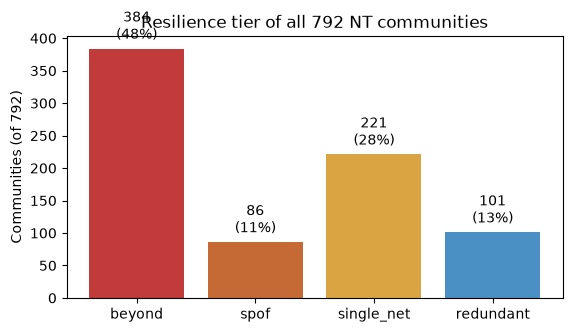

In [6]:
TIER_COLOR = {"beyond": "#C23B3B", "spof": "#C56A34", "single_net": "#D9A441", "redundant": "#4A90C4"}
order = ["beyond", "spof", "single_net", "redundant"]
counts = vg["resilience_tier"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.bar(order, counts.values, color=[TIER_COLOR[t] for t in order])
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, c + 8, f"{c}\n({c/len(vg):.0%})", ha="center", va="bottom")
ax.set_ylabel("Communities (of 792)")
ax.set_title("Resilience tier of all 792 NT communities")
plt.show()

## Conclusion

In [7]:
print("H1 SUMMARY")
print("=" * 60)
print(f"- {n_fragile}/{n_covered} covered communities ({n_fragile/n_covered:.0%}) lack a second")
print(f"  independent network: binomial test rejects H0 (p={result_v.pvalue:.2e}).")
print(f"- {n_single}/{n_towers} towers ({n_single/n_towers:.0%}) carry only one network,")
print(f"  independently confirming the finding at infrastructure level (p={result_t.pvalue:.2e}).")
print(f"- Fragility rate is {'significantly associated' if p_chi < 0.05 else 'not significantly associated'}")
print(f"  with remoteness class (chi2 p={p_chi:.2e}) — it is not random noise.")
print()
print("=> H1 is SUPPORTED: nominal mobile 'coverage' in the NT substantially overstates real")
print("   resilience to a single-network fault.")

H1 SUMMARY
- 307/408 covered communities (75%) lack a second
  independent network: binomial test rejects H0 (p=1.49e-25).
- 331/431 towers (77%) carry only one network,
  independently confirming the finding at infrastructure level (p=2.92e-30).
- Fragility rate is significantly associated
  with remoteness class (chi2 p=2.99e-19) — it is not random noise.

=> H1 is SUPPORTED: nominal mobile 'coverage' in the NT substantially overstates real
   resilience to a single-network fault.


**Ethical note.** This finding describes *infrastructure* risk, not community deficiency —
the fragility measured here is a property of carrier network topology, not of the communities
themselves. See `docs/PROJECT_CONTEXT.md` and the project report's Discussion section for the
full ethical framing (why Indigenous population share was deliberately excluded from this and
every other analysis in this project).